In [1]:
import os
import sys

#  Set the working directory to the folder containing the top-level ultralytics package
os.chdir("/workspace")  # change to your workspace root where ultralytics folder exists
print("Current working directory:", os.getcwd())


Current working directory: /workspace


In [43]:
!git clone https://github.com/danielsyahputra/yolo-distiller.git
%cd yolo-distiller


Cloning into 'yolo-distiller'...
remote: Enumerating objects: 760, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 760 (delta 0), reused 0 (delta 0), pack-reused 757 (from 3)
Receiving objects: 100% (760/760), 1.68 MiB | 1.97 MiB/s, done.
Resolving deltas: 100% (185/185), done.
Updating files: 100% (595/595), done.
/workspace/yolo-distiller


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
print("Current working directory:", os.getcwd())


Current working directory: /workspace


In [3]:
#  Add the top-level ultralytics folder to Python path
os.chdir("/workspace/yolo-distiller")
print("Current working directory:", os.getcwd())

Current working directory: /workspace/yolo-distiller


In [4]:
from ultralytics import YOLO

import ultralytics
print(ultralytics.__file__)


/workspace/yolo-distiller/ultralytics/__init__.py


In [5]:
from ultralytics.nn import tasks
from ultralytics.models.yolo.model import YOLO

model = YOLO("bestv8neiousgd.pt")
model.info()


YOLOv8n summary: 225 layers, 3,012,213 parameters, 0 gradients


(225, 3012213, 0, 0.0)

In [6]:
from ultralytics.nn import tasks
from ultralytics.models.yolo.model import YOLO

model = YOLO("bestv8leiouhyper.pt")
model.info()


YOLOv8 summary: 365 layers, 43,635,237 parameters, 0 gradients


(365, 43635237, 0, 0.0)

In [7]:
import os
print(os.getcwd())


/workspace/yolo-distiller


In [8]:
from ultralytics import YOLO
import time
import torch

# === Device setup ===
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# === Load teacher and student models ===
teacher_model = YOLO("bestv8leiouhyper.pt")        # Teacher: already trained v8l with EIoU
student_model = YOLO("bestv8neiousgd.pt")        # Student: already trained v8n with EIoU

# === Training parameters ===
dataset_yaml = "/workspace/datasets/KITTI/kitti.yml"
run_name = "yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try"  # Run name for saving logs and weights
epochs = 1
imgsz = 1280
batch_size = 32
workers = 2
patience = 20
save_interval = 50
amp = True

# === Start KD training ===
print("\n=== STARTING KNOWLEDGE DISTILLATION TRAINING ===")
start_time = time.time()

student_model.train(
    data=dataset_yaml,
    teacher=teacher_model,
    distillation_loss="cwd",   # Use CWD for feature map distillation
    epochs=epochs,
    batch=batch_size,
    imgsz=imgsz,
    workers=workers,
    device=device,
    amp=amp,
    patience=patience,
    save_period=save_interval,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=1e-4,
    cos_lr=True,
    lrf=0.01,
    augment=True,
    name=run_name
)

total_time = time.time() - start_time
print(f"\nKD Training completed in {total_time/3600:.2f} hours")



=== STARTING KNOWLEDGE DISTILLATION TRAINING ===
New https://pypi.org/project/ultralytics/8.3.207 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=bestv8neiousgd.pt, data=/workspace/datasets/KITTI/kitti.yml, epochs=1, time=None, patience=20, batch=32, imgsz=1280, save=True, save_period=50, cache=False, device=cuda:0, workers=2, project=None, name=yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_b

train: Scanning /workspace/datasets/KITTI/labels/train.cache... 5984 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5984/5984 [00:00<?, ?it/s]
val: Scanning /workspace/datasets/KITTI/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1497/1497 [00:00<?, ?it/s]


Plotting labels to /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 154 weight(decay=0.0), 168 weight(decay=0.0001), 166 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 1280 train, 1280 val
Using 2 dataloader workers
Logging results to /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try
Starting training for 1 epochs...

WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.780738830566406. Dividing input by 255.
0: 640x640 (no detections), 26.1ms
Speed: 0.0ms preprocess, 26.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/187 [00:00<?, ?it/s]


0: 1280x1280 20 Cars, 11.7ms
1: 1280x1280 1 Car, 1 Van, 1 Person_sitting, 11.7ms
2: 1280x1280 9 Cars, 11.7ms
3: 1280x1280 9 Cars, 1 Van, 1 Person_sitting, 11.7ms
4: 1280x1280 9 Cars, 1 Van, 1 Pedestrian, 2 Person_sittings, 1 Cyclist, 11.7ms
5: 1280x1280 8 Cars, 1 Van, 1 Pedestrian, 11.7ms
6: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 11.7ms
7: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 2 Person_sittings, 1 Cyclist, 11.7ms
8: 1280x1280 8 Cars, 1 Van, 3 Pedestrians, 2 Person_sittings, 11.7ms
9: 1280x1280 10 Cars, 1 Van, 1 Person_sitting, 11.7ms
10: 1280x1280 2 Cars, 11.7ms
11: 1280x1280 3 Pedestrians, 11.7ms
12: 1280x1280 7 Cars, 11.7ms
13: 1280x1280 8 Cars, 1 Pedestrian, 1 Cyclist, 11.7ms
14: 1280x1280 9 Cars, 1 Pedestrian, 11.7ms
15: 1280x1280 3 Cars, 1 Person_sitting, 11.7ms
16: 1280x1280 16 Cars, 2 Vans, 1 Pedestrian, 11.7ms
17: 1280x1280 4 Cars, 1 Pedestrian, 1 Cyclist, 11.7ms
18: 1280x1280 3 Cars, 2 Trucks, 2 Trams, 11.7ms
19: 1280x1280 10 Cars, 1 Van, 1 Truck, 11.7ms
20

...


0: 1280x1280 10 Cars, 1 Truck, 3 Pedestrians, 11.3ms
1: 1280x1280 3 Cars, 2 Vans, 7 Pedestrians, 5 Cyclists, 11.3ms
2: 1280x1280 6 Cars, 11.3ms
3: 1280x1280 3 Cars, 2 Cyclists, 11.3ms
4: 1280x1280 15 Cars, 1 Van, 11.3ms
5: 1280x1280 7 Cars, 1 Van, 1 Truck, 1 Cyclist, 11.3ms
6: 1280x1280 7 Cars, 11.3ms
7: 1280x1280 3 Cars, 11.3ms
8: 1280x1280 6 Cars, 11.3ms
9: 1280x1280 14 Cars, 1 Van, 1 Truck, 1 Cyclist, 11.3ms
10: 1280x1280 3 Cars, 2 Vans, 11.3ms
11: 1280x1280 14 Cars, 11.3ms
12: 1280x1280 8 Cars, 1 Van, 11.3ms
13: 1280x1280 6 Cars, 1 Van, 4 Pedestrians, 1 Cyclist, 11.3ms
14: 1280x1280 18 Cars, 4 Vans, 2 Pedestrians, 11.3ms
15: 1280x1280 4 Cars, 1 Van, 1 Pedestrian, 11.3ms
16: 1280x1280 2 Cars, 11.3ms
17: 1280x1280 1 Car, 1 Van, 12 Pedestrians, 1 Person_sitting, 2 Cyclists, 11.3ms
18: 1280x1280 9 Cars, 4 Vans, 1 Truck, 9 Pedestrians, 2 Person_sittings, 2 Cyclists, 11.3ms
19: 1280x1280 3 Pedestrians, 1 Cyclist, 11.3ms
20: 1280x1280 6 Cars, 3 Vans, 11.3ms
21: 1280x1280 12 Cars, 1 Truck

        1/1      28.3G     0.6301     0.4012     0.8912        360       1280: 100%|██████████| 187/187 [02:33<00:00,  1.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:07<00:00,  3.41it/s]


                   all       1497       7772      0.873      0.823      0.888      0.655

1 epochs completed in 0.047 hours.
Optimizer stripped from /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try/weights/last.pt, 6.3MB
Optimizer stripped from /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try/weights/best.pt, 6.3MB

Validating /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try/weights/best.pt...
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
YOLOv8n summary (fused): 168 layers, 3,007,013 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:07<00:00,  3.13it/s]


                   all       1497       7772      0.869      0.815      0.886      0.664
                   Car       1333       5680      0.952      0.928      0.974      0.805
                   Van        425        563      0.905      0.886      0.947      0.763
                 Truck        190        198      0.939      0.879      0.935      0.777
            Pedestrian        357        896      0.846      0.719      0.838      0.496
        Person_sitting         13         30      0.561        0.7      0.704       0.44
               Cyclist        222        306      0.942      0.803      0.912       0.65
                  Tram         76         99       0.94      0.792      0.892      0.714
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20try

KD Training completed in 0.05 hours


In [ ]:
from ultralytics import YOLO
import time
import torch

# === Device setup ===
device = "cuda:0" if torch.cuda.is_available() else "cpu"

# === Load teacher and student models ===
teacher_model = YOLO("bestv8leiouhyper.pt")        # Teacher: already trained v8l with EIoU
student_model = YOLO("bestv8neiousgd.pt")        # Student: already trained v8n with EIoU

# === Training parameters ===
dataset_yaml = "/workspace/datasets/KITTI/kitti.yml"
run_name = "yolov8nsgdlhyper_noeiouloss_KD_hyperpat20"  # Run name for saving logs and weights
epochs = 250
imgsz = 1280
batch_size = 32
workers = 2
patience = 20
save_interval = 50
amp = True

# === Start KD training ===
print("\n=== STARTING KNOWLEDGE DISTILLATION TRAINING ===")
start_time = time.time()

student_model.train(
    data=dataset_yaml,
    teacher=teacher_model,
    distillation_loss="cwd",   # Use CWD for feature map distillation
    epochs=epochs,
    batch=batch_size,
    imgsz=imgsz,
    workers=workers,
    device=device,
    amp=amp,
    patience=patience,
    save_period=save_interval,
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=1e-4,
    cos_lr=True,
    lrf=0.01,
    augment=True,
    name=run_name
)

total_time = time.time() - start_time
print(f"\nKD Training completed in {total_time/3600:.2f} hours")



=== STARTING KNOWLEDGE DISTILLATION TRAINING ===
New https://pypi.org/project/ultralytics/8.3.207 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.24 🚀 Python-3.10.12 torch-2.4.0a0+f70bd71a48.nv24.06 CUDA:0 (NVIDIA A100-SXM4-80GB, 81051MiB)
engine/trainer: task=detect, mode=train, model=bestv8neiousgd.pt, data=/workspace/datasets/KITTI/kitti.yml, epochs=250, time=None, patience=20, batch=32, imgsz=1280, save=True, save_period=50, cache=False, device=cuda:0, workers=2, project=None, name=yolov8nsgdlhyper_noeiouloss_KD_hyperpat20, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_bu

train: Scanning /workspace/datasets/KITTI/labels/train.cache... 5984 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5984/5984 [00:00<?, ?it/s]
val: Scanning /workspace/datasets/KITTI/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1497/1497 [00:00<?, ?it/s]


Plotting labels to /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 154 weight(decay=0.0), 168 weight(decay=0.0001), 166 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 1280 train, 1280 val
Using 2 dataloader workers
Logging results to /workspace/yolo-distiller/runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20
Starting training for 250 epochs...

WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.780738830566406. Dividing input by 255.
0: 640x640 (no detections), 9.0ms
Speed: 0.0ms preprocess, 9.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/187 [00:00<?, ?it/s]


0: 1280x1280 20 Cars, 11.4ms
1: 1280x1280 1 Car, 1 Van, 1 Person_sitting, 11.4ms
2: 1280x1280 9 Cars, 11.4ms
3: 1280x1280 9 Cars, 1 Van, 1 Person_sitting, 11.4ms
4: 1280x1280 9 Cars, 1 Van, 1 Pedestrian, 2 Person_sittings, 1 Cyclist, 11.4ms
5: 1280x1280 8 Cars, 1 Van, 1 Pedestrian, 11.4ms
6: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 1 Person_sitting, 11.4ms
7: 1280x1280 3 Cars, 1 Van, 1 Pedestrian, 2 Person_sittings, 1 Cyclist, 11.4ms
8: 1280x1280 8 Cars, 1 Van, 3 Pedestrians, 2 Person_sittings, 11.4ms
9: 1280x1280 10 Cars, 1 Van, 1 Person_sitting, 11.4ms
10: 1280x1280 2 Cars, 11.4ms
11: 1280x1280 3 Pedestrians, 11.4ms
12: 1280x1280 7 Cars, 11.4ms
13: 1280x1280 8 Cars, 1 Pedestrian, 1 Cyclist, 11.4ms
14: 1280x1280 9 Cars, 1 Pedestrian, 11.4ms
15: 1280x1280 3 Cars, 1 Person_sitting, 11.4ms
16: 1280x1280 16 Cars, 2 Vans, 1 Pedestrian, 11.4ms
17: 1280x1280 4 Cars, 1 Pedestrian, 1 Cyclist, 11.4ms
18: 1280x1280 3 Cars, 2 Trucks, 2 Trams, 11.4ms
19: 1280x1280 10 Cars, 1 Van, 1 Truck, 11.4ms
20

...

     12/250      28.3G     0.6698     0.4293     0.9115        436       1280:  62%|██████▏   | 116/187 [01:34<00:57,  1.24it/s]


0: 1280x1280 9 Cars, 11.3ms
1: 1280x1280 9 Cars, 1 Pedestrian, 1 Cyclist, 11.3ms
2: 1280x1280 12 Cars, 3 Vans, 1 Truck, 2 Cyclists, 11.3ms
3: 1280x1280 11 Cars, 1 Van, 2 Pedestrians, 11.3ms
4: 1280x1280 5 Cars, 2 Vans, 1 Pedestrian, 2 Cyclists, 4 Trams, 11.3ms
5: 1280x1280 8 Cars, 1 Van, 11.3ms
6: 1280x1280 9 Cars, 1 Truck, 11.3ms
7: 1280x1280 11 Cars, 3 Vans, 1 Cyclist, 11.3ms
8: 1280x1280 1 Pedestrian, 1 Cyclist, 11.3ms
9: 1280x1280 5 Cars, 2 Vans, 8 Pedestrians, 2 Cyclists, 11.3ms
10: 1280x1280 1 Car, 1 Cyclist, 11.3ms
11: 1280x1280 5 Cars, 11.3ms
12: 1280x1280 17 Cars, 1 Cyclist, 11.3ms
13: 1280x1280 7 Cars, 2 Trucks, 3 Pedestrians, 11.3ms
14: 1280x1280 30 Cars, 1 Cyclist, 11.3ms
15: 1280x1280 12 Cars, 2 Vans, 1 Truck, 4 Pedestrians, 1 Cyclist, 11.3ms
16: 1280x1280 5 Cars, 1 Truck, 11.3ms
17: 1280x1280 8 Cars, 3 Vans, 1 Truck, 4 Pedestrians, 11.3ms
18: 1280x1280 9 Cars, 11.3ms
19: 1280x1280 6 Cars, 1 Van, 3 Pedestrians, 1 Cyclist, 11.3ms
20: 1280x1280 15 Cars, 2 Vans, 11.3ms
21: 1

     12/250      28.3G     0.6699     0.4295     0.9115        329       1280:  63%|██████▎   | 117/187 [01:35<00:56,  1.24it/s]


0: 1280x1280 11 Cars, 1 Van, 1 Truck, 1 Pedestrian, 11.3ms
1: 1280x1280 18 Cars, 2 Vans, 2 Pedestrians, 11.3ms
2: 1280x1280 25 Cars, 2 Vans, 1 Cyclist, 11.3ms
3: 1280x1280 1 Car, 11.3ms
4: 1280x1280 5 Cars, 1 Pedestrian, 11.3ms
5: 1280x1280 1 Car, 11.3ms
6: 1280x1280 3 Cars, 11.3ms
7: 1280x1280 17 Cars, 1 Van, 4 Pedestrians, 11.3ms
8: 1280x1280 (no detections), 11.3ms
9: 1280x1280 9 Cars, 3 Vans, 1 Truck, 11.3ms
10: 1280x1280 4 Cars, 2 Vans, 4 Pedestrians, 11.3ms
11: 1280x1280 8 Cars, 1 Truck, 1 Pedestrian, 11.3ms
12: 1280x1280 2 Cars, 1 Cyclist, 11.3ms
13: 1280x1280 10 Cars, 1 Van, 5 Pedestrians, 11.3ms
14: 1280x1280 16 Cars, 1 Van, 1 Truck, 1 Pedestrian, 1 Cyclist, 11.3ms
15: 1280x1280 12 Cars, 1 Van, 1 Truck, 4 Pedestrians, 11.3ms
16: 1280x1280 2 Cars, 1 Truck, 11.3ms
17: 1280x1280 10 Cars, 1 Cyclist, 11.3ms
18: 1280x1280 12 Cars, 3 Vans, 1 Cyclist, 11.3ms
19: 1280x1280 8 Cars, 1 Van, 1 Pedestrian, 1 Cyclist, 11.3ms
20: 1280x1280 (no detections), 11.3ms
21: 1280x1280 5 Cars, 2 Vans

     12/250      28.3G     0.6698     0.4294     0.9115        363       1280:  63%|██████▎   | 118/187 [01:36<00:55,  1.24it/s]

In [10]:
import sys
from pathlib import Path
import torch
import time
from ultralytics import YOLO  # Use YOLOv8's interface

weights = "runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20/weights/best.pt"
dataset_yaml = "/workspace/datasets/KITTI/kitti.yml"
results_dir = "/workspace/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20_distill"

# ------------------- Device -------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ------------------- Load model -------------------
model = YOLO(weights)  # Load the model using YOLOv8
params = sum(p.numel() for p in model.model.parameters())
params_mb = params * 4 / (1024**2)  # float32 -> 4 bytes
model_size_mb = Path(weights).stat().st_size / 1024**2  # file size in MB

print(f"Model size (file): {model_size_mb:.2f} MB")
print(f"Model parameters: {params_mb:.2f} MB")

# ------------------- FPS Measurement -------------------
dummy_input = torch.randn(1, 3, 1280, 1280).to(device) / 255.0  # Normalize the dummy input
# Warm-up
for _ in range(5):
    _ = model(dummy_input)  # Use the model directly for inference

n_runs = 50
start_time = time.time()
for _ in range(n_runs):
    _ = model(dummy_input)  # Use the model directly for inference
end_time = time.time()

fps = n_runs / (end_time - start_time)
print(f"Inference FPS (1280x1280): {fps:.2f}")

# ------------------- Run Validation -------------------
print("\nRunning YOLOv8 validation...")
start_val_time = time.time()
model.val(
    data=dataset_yaml,  # Validation dataset
    imgsz=1280,          # Image size
    batch=64,            # Corrected batch size argument
    device=device,       # Device
    project=results_dir, # Results directory
    name="eval_metrics", # Name for saved results
    save_json=True,      # Save results as JSON
    exist_ok=True,       # Overwrite if results directory exists
    verbose=True         # Show verbose output
)
end_val_time = time.time()

val_time = end_val_time - start_val_time
print(f"Validation time: {val_time:.2f} seconds")
print(f"Validation results saved to {results_dir}")


Model size (file): 6.00 MB
Model parameters: 11.49 MB

0: 1280x1280 (no detections), 4.9ms
Speed: 0.0ms preprocess, 4.9ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.1ms
Speed: 0.0ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.1ms
Speed: 0.0ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.2ms
Speed: 0.0ms preprocess, 5.2ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.1ms
Speed: 0.0ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.1ms
Speed: 0.0ms preprocess, 5.1ms inference, 1.3ms postprocess per image at shape (1, 3, 1280, 1280)

0: 1280x1280 (no detections), 5.1ms
Speed: 0.0ms preprocess, 5.1ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 1280)



val: Scanning /workspace/datasets/KITTI/labels/val.cache... 1497 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1497/1497 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:08<00:00,  2.67it/s]


                   all       1497       7772      0.917      0.895      0.935      0.757
                   Car       1333       5680      0.963      0.961      0.987      0.878
                   Van        425        563      0.956      0.959      0.981      0.866
                 Truck        190        198      0.964      0.942      0.968      0.871
            Pedestrian        357        896      0.944      0.804      0.909      0.577
        Person_sitting         13         30      0.757      0.733      0.785      0.524
               Cyclist        222        306      0.928      0.899      0.947      0.747
                  Tram         76         99      0.906       0.97      0.968      0.834
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving /workspace/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20_distill/eval_metrics/predictions.json...
Results saved to /workspace/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20_distill/eval_metrics
Validation tim

In [12]:
import numpy as np
import pandas as pd

# -----------------------------
# CONFIGURATION
# -----------------------------
class_names = ["Car", "Van", "Truck", "Pedestrian", "Person_sitting", "Cyclist", "Tram"]
num_classes = len(class_names)

# -----------------------------
# CONFUSION MATRIX (predicted rows x true cols)
# -----------------------------
conf_matrix = np.array([
    [5530, 9, 0, 1, 0, 2, 0, 338],
    [4, 536, 3, 0, 0, 0, 0, 36],
    [0, 0, 189, 0, 0, 0, 0, 13],
    [0, 0, 0, 798, 0, 2, 0, 145],
    [0, 0, 0, 0, 26, 0, 0, 12],
    [0, 0, 0, 1, 0, 277, 0, 36],
    [0, 0, 0, 0, 0, 0, 94, 9],
    [146, 18, 6, 96, 4, 25, 5, n]
])

# -----------------------------
# PER-CLASS LOG
# -----------------------------
per_class_precision = [0.962, 0.958, 0.957, 0.936, 0.796, 0.937, 0.946]  
per_class_recall =    [0.964, 0.954, 0.944, 0.822, 0.833, 0.889, 0.949]  
per_class_map50 = [0.984, 0.974, 0.979, 0.913, 0.847, 0.944, 0.963]
per_class_map5095 = [0.879, 0.862, 0.877, 0.583, 0.583, 0.753, 0.851]

# -----------------------------
# COMPUTE METRICS
# -----------------------------
metrics_data = []
total_samples = np.sum(conf_matrix)

for i, cname in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = np.sum(conf_matrix[i, :]) - TP
    FN = np.sum(conf_matrix[:, i]) - TP
    TN = total_samples - (TP + FP + FN)

    #Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    #Recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    Precision = per_class_precision[i] 
    Recall = per_class_recall[i]        
    F1 = 2 * Precision * Recall / (Precision + Recall) if (Precision + Recall) > 0 else 0
    Accuracy = (TP + TN) / total_samples if total_samples > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
    FNR = FN / (FN + TP) if (FN + TP) > 0 else 0

    metrics_data.append({
        "Class": cname,
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN),
        "Precision": round(per_class_precision[i], 4),
        "Recall": round(per_class_recall[i], 4),
        "F1 Score": round(F1, 4),
        "Accuracy": round(Accuracy, 4),
        "FPR": round(FPR, 4),
        "FNR": round(FNR, 4),
        "mAP@0.5": per_class_map50[i],
        "mAP@0.5:0.95": per_class_map5095[i]
    })

# -----------------------------
# OVERALL ROW
# -----------------------------
TP_total = sum(row["TP"] for row in metrics_data)
FP_total = sum(row["FP"] for row in metrics_data)
FN_total = sum(row["FN"] for row in metrics_data)
TN_total = sum(row["TN"] for row in metrics_data)

overall = {
    "Class": "Overall",
    "TP": TP_total,
    "FP": FP_total,
    "FN": FN_total,
    "TN": TN_total,
    "Precision": np.mean([row["Precision"] for row in metrics_data]),
    "Recall": np.mean([row["Recall"] for row in metrics_data]),
    "F1 Score": np.mean([row["F1 Score"] for row in metrics_data]),
    "Accuracy": np.mean([row["Accuracy"] for row in metrics_data]),
    "FPR": np.mean([row["FPR"] for row in metrics_data]),
    "FNR": np.mean([row["FNR"] for row in metrics_data]),
    "mAP@0.5": np.mean([row["mAP@0.5"] for row in metrics_data]),
    "mAP@0.5:0.95": np.mean([row["mAP@0.5:0.95"] for row in metrics_data])
}

metrics_data.append(overall)

# -----------------------------
# SAVE TO CSV
# -----------------------------
df_metrics = pd.DataFrame(metrics_data)
df_metrics.to_csv("yolov8nsgdlhyper_noeiouloss_KD_hyperpat20_metrics.csv", index=False)
print(df_metrics)


NameError: name 'n' is not defined


image 1/1 /workspace/000007.png: 416x1280 4 Cars, 1 Tram, 254.4ms
Speed: 5.1ms preprocess, 254.4ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 1280)


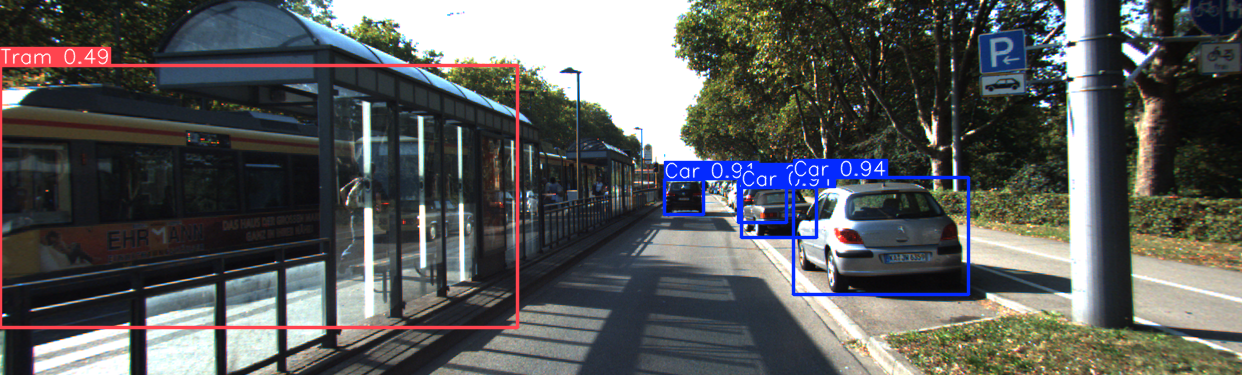

In [11]:
from ultralytics import YOLO

# Try loading and running inference with the trained model
model = YOLO("runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20/weights/best.pt")  # path to your trained model
results = model.predict("/workspace/000007.png")  # use any sample image
results[0].show()


In [22]:
import shutil

# Specify the folder path and the destination zip file path
folder_path = '/workspace/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20_distill'
zip_file_path = '/workspace/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20_distill.zip'

# Create a zip file from the folder
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

'/workspace/yolov8nciouleiou_eiouloss_KD_hyperpat20_0.0005lr_distill.zip'

In [23]:
import shutil

# Specify the folder path and the destination zip file path
folder_path = 'runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20'
zip_file_path = 'runs/detect/yolov8nsgdlhyper_noeiouloss_KD_hyperpat20.zip'

# Create a zip file from the folder
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

'/workspace/yolo-distiller/runs/detect/yolov8nciouleiou_eiouloss_KD_hyperpat20_0.0005lr.zip'